In [1]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, roc_auc_score
)
from sklearn.model_selection import GridSearchCV

# Statistical modeling
import statsmodels.api as sm

# Ignore warnings (clean output)
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("data/diabetes.csv")
# lot of missing values hence these columns are dropped
# can we drop pressure?
df = df.drop(columns = ['Insulin', 'SkinThickness'])
df_reduced = df.drop(columns = [ 'BloodPressure', 'Age'])
print("--- df ---")
print(df.head())
print(df.info())
print(df.describe())

print("--- df_reduced ---")
print(df_reduced.head())
print(df_reduced.info())
print(df_reduced.describe())

--- df ---
   Pregnancies  Glucose  BloodPressure   BMI  DiabetesPedigreeFunction  Age  \
0            6      148             72  33.6                     0.627   50   
1            1       85             66  26.6                     0.351   31   
2            8      183             64  23.3                     0.672   32   
3            1       89             66  28.1                     0.167   21   
4            0      137             40  43.1                     2.288   33   

   Outcome  
0        1  
1        0  
2        1  
3        0  
4        1  
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   BMI                       768 non-null    float64
 4   Diabetes

In [3]:
cols_with_zero = ["Glucose", "BloodPressure", "BMI"]
cols_with_zero_reduced = ["Glucose", "BMI"]

# Replace 0 with NaN
df[cols_with_zero] = df[cols_with_zero].replace(0, np.nan)
df_reduced[cols_with_zero_reduced] = df_reduced[cols_with_zero_reduced].replace(0, np.nan)

for col in cols_with_zero:
    df[col] = df[col].fillna(df[col].median())
for col in cols_with_zero_reduced:
    df_reduced[col] = df_reduced[col].fillna(df_reduced[col].median())

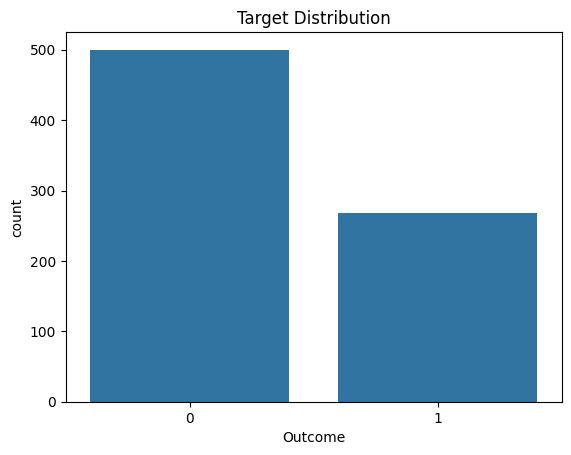

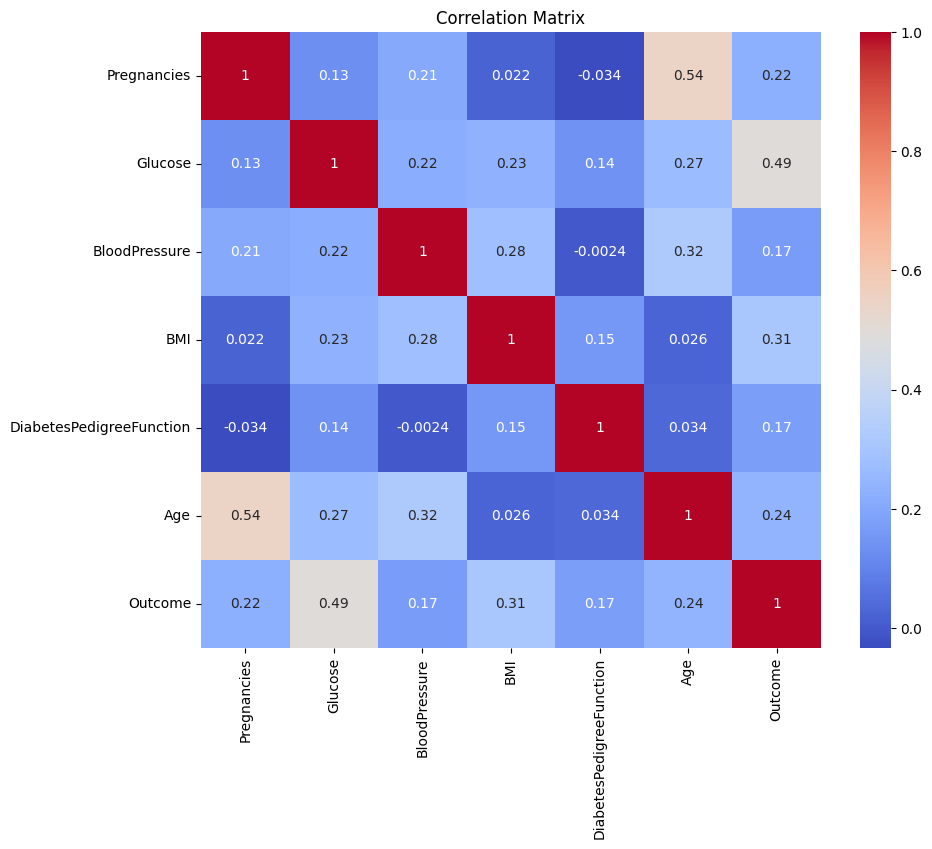

In [4]:
sns.countplot(x=df["Outcome"])
plt.title("Target Distribution")
plt.show()
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [5]:
X = df.drop("Outcome", axis=1)
X_reduced = df_reduced.drop("Outcome", axis=1)
y = df["Outcome"]
# stratify=y maintains class balance in train/test

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_reduced, X_test_reduced, y_train_reduced, y_test_reduced = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_scaled_reduced = scaler.fit_transform(X_train_reduced)
X_test_scaled_reduced = scaler.transform(X_test_reduced)

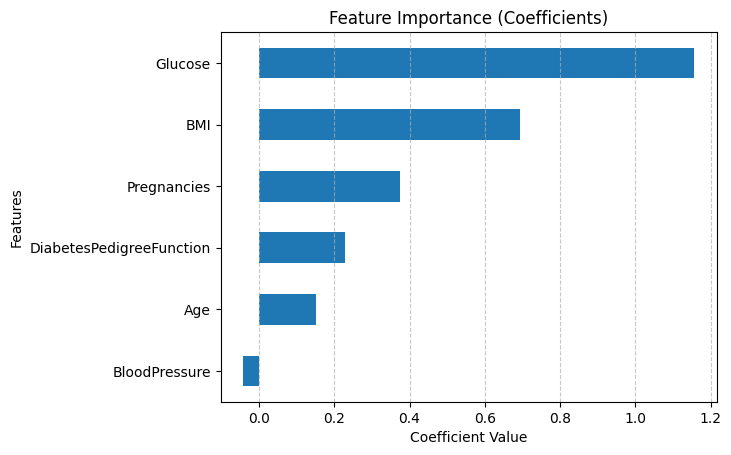

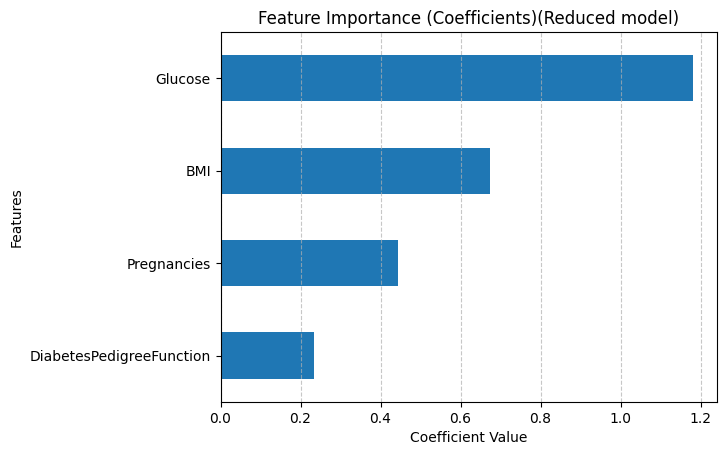

In [6]:
model = LogisticRegression()

model.fit(X_train_scaled, y_train)
coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0],
})

coeff_df.set_index('Feature', inplace=True)
coeff_df.sort_values(by="Coefficient").plot(kind='barh', legend=False)
plt.title("Feature Importance (Coefficients)")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.grid(axis='x', linestyle='--', alpha=0.7) 
plt.show()

model_reduced = LogisticRegression()

model_reduced.fit(X_train_scaled_reduced, y_train_reduced)
coeff_df_reduced = pd.DataFrame({
    "Feature": X_reduced.columns,
    "Coefficient": model_reduced.coef_[0],
})

coeff_df_reduced.set_index('Feature', inplace=True)
coeff_df_reduced.sort_values(by="Coefficient").plot(kind='barh', legend=False)
plt.title("Feature Importance (Coefficients)(Reduced model)")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.grid(axis='x', linestyle='--', alpha=0.7) 
plt.show()

In [7]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Computing Youden’s J statistic
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
j_scores = tpr - fpr
best_index = np.argmax(j_scores)
best_threshold = thresholds[best_index]
threshold = best_threshold
y_pred_new = (y_prob >= threshold).astype(int)
print("Optimal Threshold: ", threshold)

y_pred_reduced = model_reduced.predict(X_test_scaled_reduced)
y_prob_reduced = model_reduced.predict_proba(X_test_scaled_reduced)[:, 1]

# Computing Youden’s J statistic
fpr, tpr, thresholds = roc_curve(y_test_reduced, y_prob_reduced)
j_scores = tpr - fpr
best_index = np.argmax(j_scores)
best_threshold = thresholds[best_index]
threshold_reduced = best_threshold
y_pred_new_reduced = (y_prob_reduced >= threshold_reduced).astype(int)
print("Optimal Threshold(Reduced model): ", threshold_reduced)

Optimal Threshold:  0.23886961809208726
Optimal Threshold(Reduced model):  0.2588376766945737



--- Final Performance Comparison ---
   Metric  Full Model (0.5)  Full Model (0.2389)  Reduced Model (0.2588)
 Accuracy          0.701299             0.733766                0.740260
Precision          0.590909             0.578313                0.585366
   Recall          0.481481             0.888889                0.888889
 F1 Score          0.530612             0.700730                0.705882
  AUC-ROC          0.812407             0.812407                0.810741


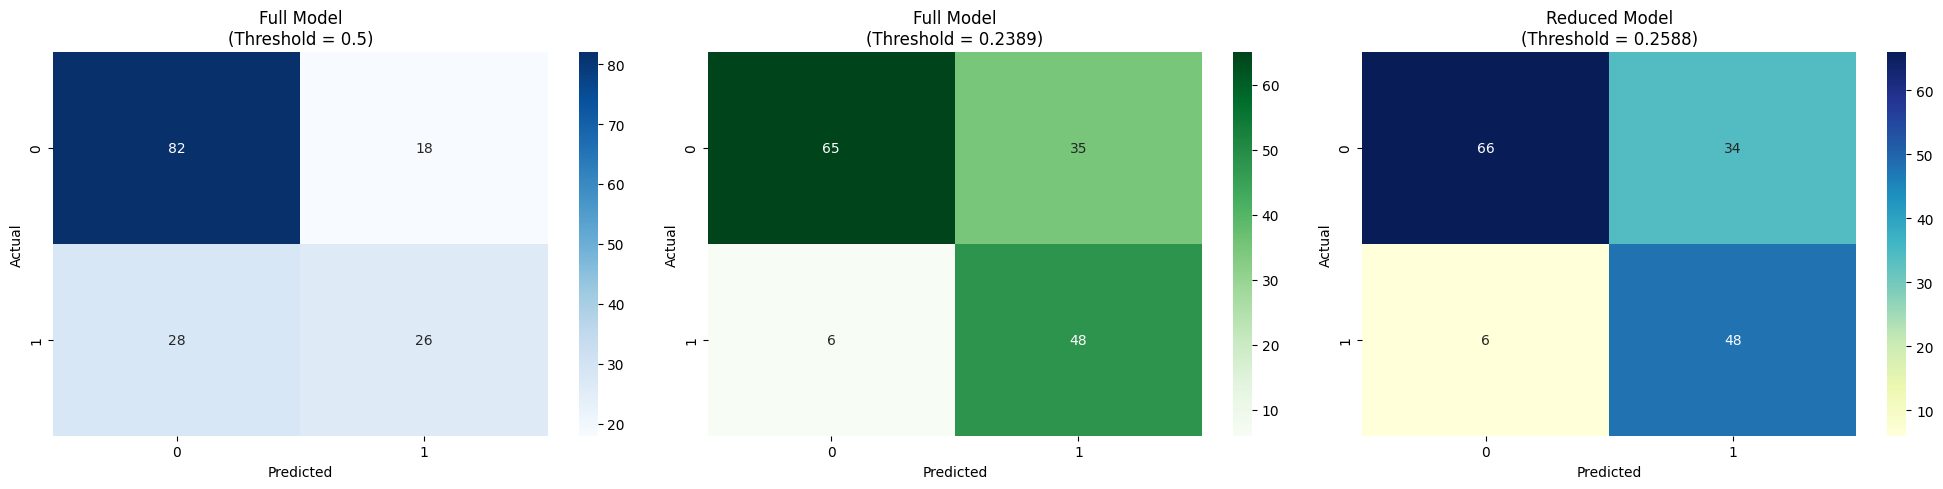

In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Function to calculate metrics and return a list
def get_model_metrics(y_true, y_pred, y_prob):
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred),
        recall_score(y_true, y_pred),
        f1_score(y_true, y_pred),
        roc_auc_score(y_true, y_prob)
    ]

# 1. Gather all numerical data
results = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "AUC-ROC"],
    
    "Full Model (0.5)": get_model_metrics(y_test, y_pred, y_prob),
    
    f"Full Model ({threshold:.4f})": get_model_metrics(y_test, y_pred_new, y_prob),
    
    f"Reduced Model ({threshold_reduced:.4f})": get_model_metrics(y_test_reduced, y_pred_new_reduced, y_prob_reduced)
}

# 2. Create and Print the Comparison Table
df_results = pd.DataFrame(results)
print("\n--- Final Performance Comparison ---")
print(df_results.to_string(index=False))

# 3. Plotting the 3 Confusion Matrices Side-by-Side
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Plot 1: Full Model (0.5)
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Full Model\n(Threshold = 0.5)")

# Plot 2: Full Model (Optimal)
sns.heatmap(confusion_matrix(y_test, y_pred_new), annot=True, fmt="d", cmap="Greens", ax=axes[1])
axes[1].set_title(f"Full Model\n(Threshold = {threshold:.4f})")

# Plot 3: Reduced Model (Optimal)
sns.heatmap(confusion_matrix(y_test_reduced, y_pred_new_reduced), annot=True, fmt="d", cmap="YlGnBu", ax=axes[2])
axes[2].set_title(f"Reduced Model\n(Threshold = {threshold_reduced:.4f})")

for ax in axes:
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()